# Jaguar Re-ID — ViT Improved v3

**Architecture** : ViT + `relu` (naïf du cours, mais `tanh` remplace par `relu` qui debloque l'apprentissage).  
**Changement principal** : **fixer le retrain sous-entraine** de la premiere tentative v3 (47.6% train → Kaggle 0.097).  

### Diagnostic de la tentative v3 initiale

| Phase | Epochs | Train Acc |
|-------|--------|-----------|
| Sweep (LR=1e-4) | 16 (best) | 98.15 % |
| Retrain final | 16 (= BEST_EPOCH) | **47.60 %** ❌ |

Le retrain `from scratch` sur plus de donnees (1895 vs 1516) n'atteint pas la convergence en 16 epochs a LR=1e-4. Le modele extrait des embeddings quasi-aleatoires → Kaggle 0.097.

### Fix applique dans ce notebook

- **`RETRAIN_EPOCHS_MULTIPLIER = 4`** : entrainer le retrain pendant `4 × BEST_EPOCH` epochs (minimum 60). Donne au LR=1e-4 le temps de converger.
- **Monitoring** : afficher la courbe train loss/accuracy du retrain pour verifier la convergence.
- **Cible** : retrain train_acc > 90 % avant extraction des embeddings.

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776548458.633958   60024 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776548459.185877   60024 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776548460.789086   60024 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776548462.636300   60024 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [ ]:
MODEL_NAME   = 'vit_improved_v3'
AUGMENTATION = 'none'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

# ViT architecture hyperparameters
EMBED_DIM  = 64      # Patch embedding dimension
NUM_BLOCKS = 3       # Number of transformer blocks
PATCH_SIZE = 16      # Patch size (16x16 pixels)
ACTIVATION = 'relu'  # tanh → relu (debloque l'apprentissage)

# Retrain fix
RETRAIN_EPOCHS_MULTIPLIER = 4   # retrain = max(4 * BEST_EPOCH, RETRAIN_EPOCHS_MIN)
RETRAIN_EPOCHS_MIN        = 60  # garantie minimale pour laisser LR=1e-4 converger

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

W0000 00:00:1776548466.769458   60024 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776548466.959645   60024 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

Architecture **identique a v3** — on isole l'effet du fix retrain.

| Parametre | v3 | v4 | Pourquoi |
|-----------|----|----|----------|
| Architecture | ViT + `relu` | ViT + `relu` (idem) | On garde tout identique |
| Retrain epochs | `BEST_EPOCH` (=16) | **`max(4*BEST_EPOCH, 60)`** | LR=1e-4 lent, besoin de plus d'epochs pour converger sur 1895 images |

In [4]:
def positional_embedding(embedded_patches):
    """One-hot positional encoding (cours) : concat one-hot(position) to each patch."""
    embedded_patches_shape = tf.shape(embedded_patches)
    batchsize = embedded_patches_shape[0]
    sequence_length = embedded_patches_shape[1]
    indices = tf.range(sequence_length)
    one_hot_indices = tf.one_hot(indices, sequence_length)
    expanded_one_hot_indices = tf.expand_dims(one_hot_indices, axis=0)
    repeated_expanded_one_hot_indices = tf.repeat(expanded_one_hot_indices, [batchsize], axis=0)
    positional_embedded_patches = tf.concat([repeated_expanded_one_hot_indices, embedded_patches], axis=-1)
    return positional_embedded_patches


def build_model():
    input_tensor = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = input_tensor

    # Patch embedding
    x = layers.Conv2D(EMBED_DIM, (PATCH_SIZE, PATCH_SIZE), strides=(PATCH_SIZE, PATCH_SIZE),
                      activation='linear', use_bias=False, padding='valid')(x)
    sequence_length = x.shape[1] * x.shape[2]  # 14*14 = 196
    sqrt_sequence_length = np.sqrt(sequence_length)

    x = layers.Reshape((sequence_length, EMBED_DIM))(x)

    # Positional encoding : one-hot concat
    x = layers.Lambda(positional_embedding)(x)
    real_embedding_dim = sequence_length + EMBED_DIM  # 196 + 64 = 260

    # Transformer blocks
    for _ in range(NUM_BLOCKS):
        # Self-attention
        old_x = x
        x = layers.LayerNormalization()(x)

        Q = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        K = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        V = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)

        Kt = layers.Lambda(lambda t: tf.transpose(t, [0, 2, 1]))(K)
        QKt = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]) / sqrt_sequence_length)([Q, Kt])
        Masks = layers.Softmax()(QKt)
        x = layers.Lambda(lambda ts: tf.matmul(ts[0], ts[1]))([Masks, V])
        x = layers.Add()([x, old_x])

        # Feed-forward
        old_x = x
        x = layers.LayerNormalization()(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Dense(real_embedding_dim, activation=ACTIVATION)(x)
        x = layers.Add()([x, old_x])

    # Classification head
    x = layers.Flatten()(x)
    x = layers.Dense(real_embedding_dim, activation=ACTIVATION, name='embedding')(x)
    output_tensor = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(input_tensor, output_tensor, name=MODEL_NAME)
    return model


model = build_model()
model.summary()

Model: "vit_improved_v4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │     49,152 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 196, 64)   │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 196, 260)  │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 260)  │        520 │ lambda[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 260, 196)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 196, 196)  │          0 │ dense[0][0],      │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 196, 196)  │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 196, 260)  │          0 │ softmax[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 260)  │          0 │ lambda_3[0][0],   │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 260)  │     67,860 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 260)  │          0 │ dense_4[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 260)  │        520 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 196, 260)  │     67,860 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 14,328,123 (54.66 MB)

 Trainable params: 14,328,123 (54.66 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter sweep

Meme sweep que v3. On s'attend a retrouver `BEST_LR = 1e-4` (variance possible entre runs).

In [5]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (vit_improved_v4) ===


I0000 00:00:1776548471.676846   60136 service.cc:153] XLA service 0x7fb0c8048750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776548471.676883   60136 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776548471.762645   60136 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776548472.260850   60136 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776548472.290823   60136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10106__.100
I0000 00:00:1776548472.599703   60266 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_74', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776548472.725560   60262 subprocess_compilation.cc:348] ptxa

  lr_0.01: val_acc=0.0950 (best epoch=21)


I0000 00:00:1776548522.640903   60137 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45486__.100
I0000 00:00:1776548526.323938   60138 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_45486__.100
I0000 00:00:1776548529.414173   60139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46828__.28
I0000 00:00:1776548530.543077   60138 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_46828__.28


  lr_0.001: val_acc=0.6966 (best epoch=9)


I0000 00:00:1776548542.948454   60138 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70812__.100
I0000 00:00:1776548546.642587   60137 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70812__.100
I0000 00:00:1776548549.729901   60139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_72154__.28
I0000 00:00:1776548550.896249   60136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_72154__.28


  lr_0.0005: val_acc=0.5752 (best epoch=10)


I0000 00:00:1776548564.209528   60138 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97062__.100
I0000 00:00:1776548567.835440   60136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97062__.100
I0000 00:00:1776548570.888344   60137 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98404__.28
I0000 00:00:1776548572.058689   60136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98404__.28


  lr_0.0001: val_acc=0.6992 (best epoch=17)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")
print(f"BEST_LR = {BEST_LR}, BEST_EPOCH = {BEST_EPOCH}")

,Config,Val Accuracy,Best Epoch
0,lr_0.0001,0.699208,17
1,lr_0.001,0.696570,9
2,lr_0.0005,0.575198,10
3,lr_0.01,0.094987,21



Best: lr_0.0001 → val_acc=0.6992
BEST_LR = 0.0001, BEST_EPOCH = 17


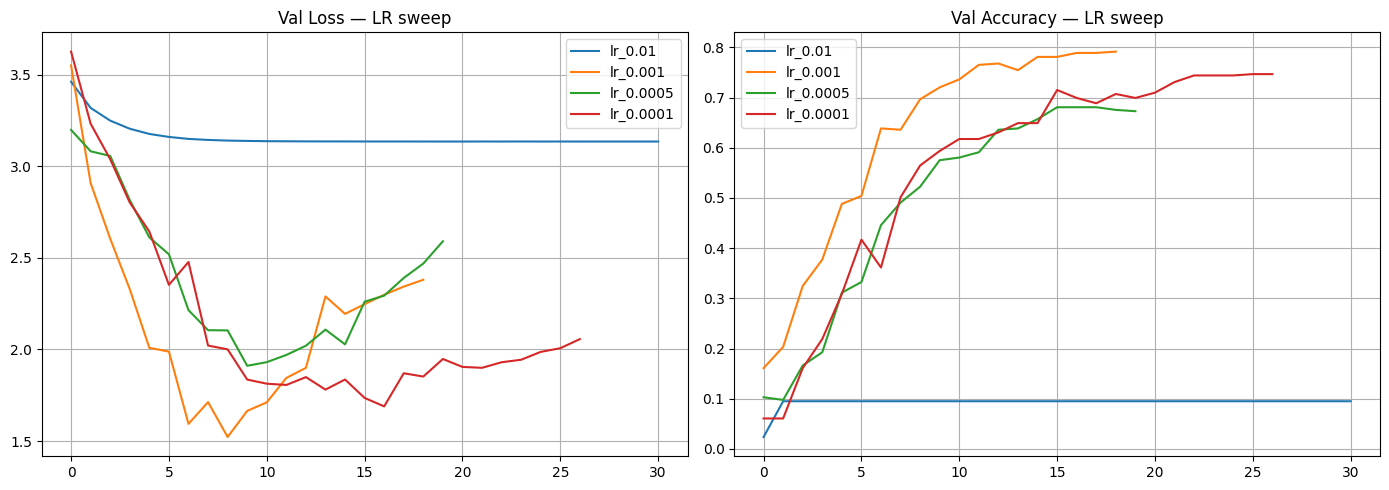

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776548588.966024   60136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128840__.100


46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0475 - loss: 9.6403 

I0000 00:00:1776548592.743491   60136 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_128840__.100


48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.0483 - loss: 9.5111

I0000 00:00:1776548595.520576   60138 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130182__.28
I0000 00:00:1776548596.684804   60139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130182__.28


48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 139ms/step - accuracy: 0.0666 - loss: 6.5274 - val_accuracy: 0.0950 - val_loss: 3.5128 - learning_rate: 1.0000e-04
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1154 - loss: 3.2293 - val_accuracy: 0.1478 - val_loss: 3.1334 - learning_rate: 1.0000e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2091 - loss: 2.8986 - val_accuracy: 0.3008 - val_loss: 2.6469 - learning_rate: 1.0000e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3094 - loss: 2.5158 - val_accuracy: 0.3799 - val_loss: 2.3900 - learning_rate: 1.0000e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4136 - loss: 2.1760 - val_accuracy: 0.4380 - val_loss: 2.2305 - learning_rate: 1.0000e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5020 - loss: 1.8374 - val_accuracy: 0.5040 - val_loss: 1.9809 - learning_rate: 1.0000e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5726 - l

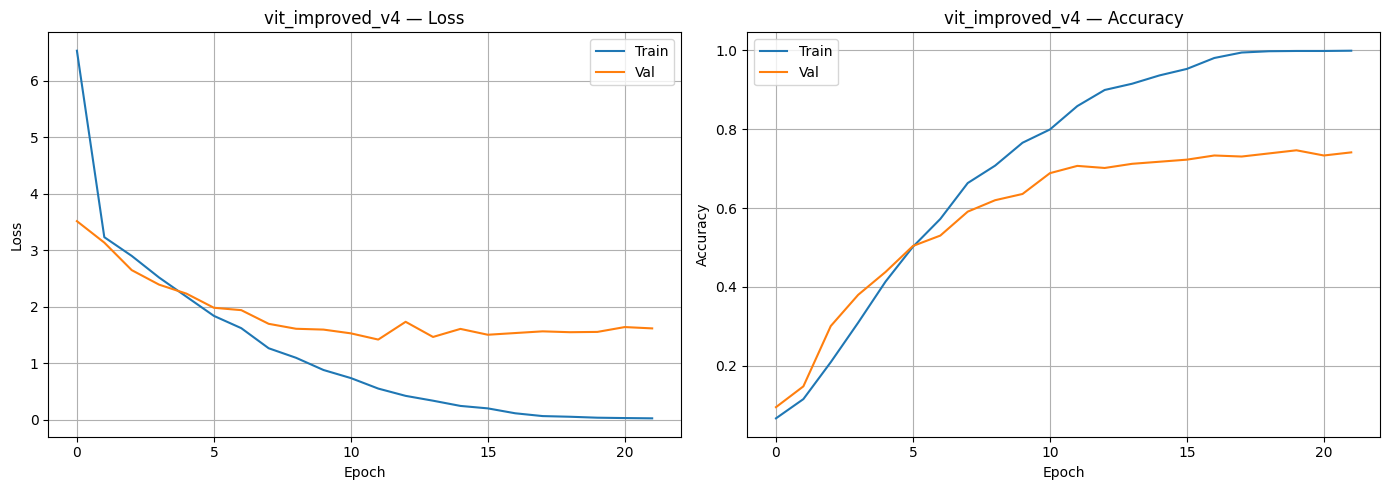

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

I0000 00:00:1776548618.491142   60138 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_130182__.28


vit_improved_v4 (best LR=0.0001):
  Train — Loss: 0.3987, Acc: 0.9109
  Val   — Loss: 1.4184, Acc: 0.7071


I0000 00:00:1776548619.665510   60139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_288402__.21
I0000 00:00:1776548620.843644   60138 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_288893__.21


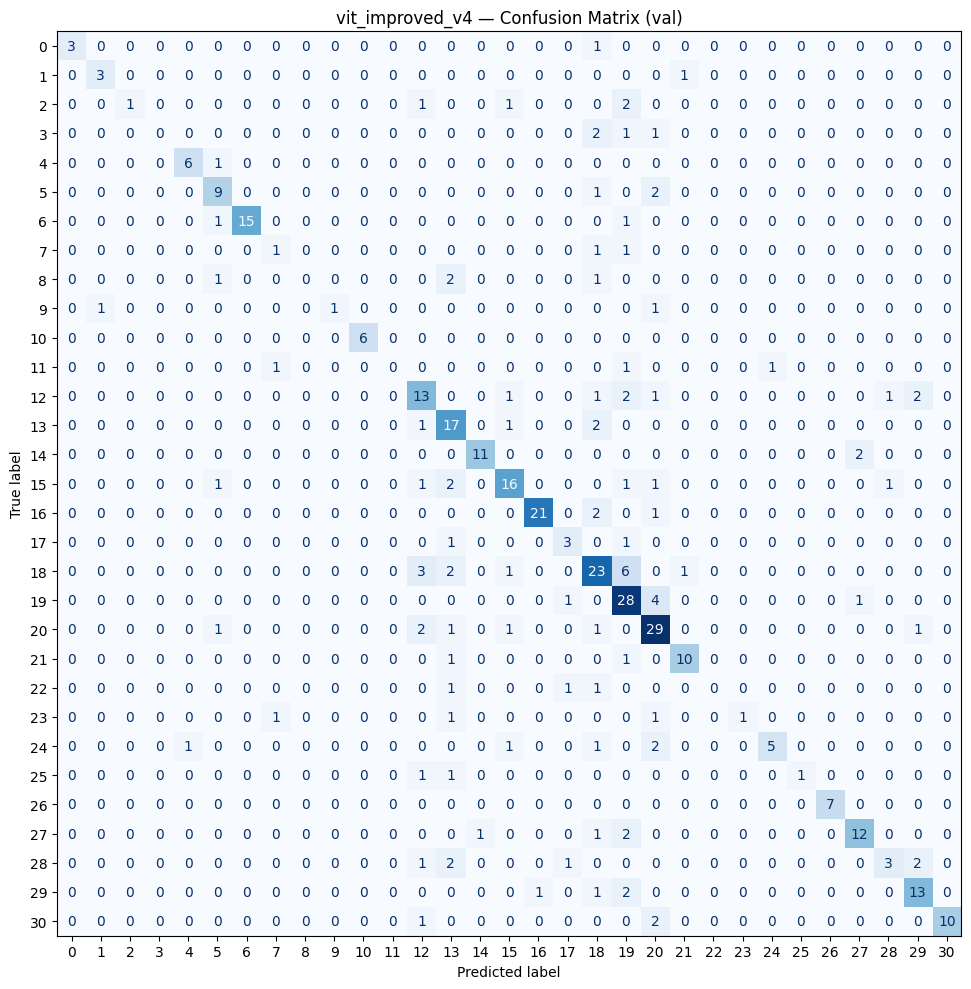

In [12]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

**Fix v4** : retrain pour `max(4*BEST_EPOCH, 60)` epochs au lieu de `BEST_EPOCH` seul.

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION, batch_size=BATCH_SIZE)

# Fix v4 : decouple retrain epochs de BEST_EPOCH
RETRAIN_EPOCHS = max(BEST_EPOCH * RETRAIN_EPOCHS_MULTIPLIER, RETRAIN_EPOCHS_MIN)
print(f"BEST_EPOCH du sweep : {BEST_EPOCH}")
print(f"RETRAIN_EPOCHS (v4) : {RETRAIN_EPOCHS}  (= max({BEST_EPOCH}*{RETRAIN_EPOCHS_MULTIPLIER}, {RETRAIN_EPOCHS_MIN}))")
print(f"Retraining on full dataset ({len(X_all)} images) for {RETRAIN_EPOCHS} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_history = final_model.fit(
    all_ds, epochs=RETRAIN_EPOCHS,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
final_train_acc = final_model.evaluate(all_ds, verbose=0)[1]
print(f"\nFinal retrain train acc: {final_train_acc:.4f}")

BEST_EPOCH du sweep : 17
RETRAIN_EPOCHS (v4) : 68  (= max(17*4, 60))
Retraining on full dataset (1895 images) for 68 epochs
Epoch 1/68


I0000 00:00:1776548626.649127   60137 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_298616__.100


57/60 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0478 - loss: 8.5519

I0000 00:00:1776548630.544567   60138 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_298616__.100
I0000 00:00:1776548630.811502   70940 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_140', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776548630.837801   70945 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_140', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776548630.867972   70934 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_140', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776548631.297616   70947 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_40', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776548631.482792   70941 subprocess_compilati

60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 205ms/step - accuracy: 0.0691 - loss: 5.4924
Epoch 2/68
 1/60 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.0625 - loss: 3.3216

I0000 00:00:1776548641.595336   60138 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_select_fusion_1', 56 bytes spill stores, 56 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_select_fusion', 56 bytes spill stores, 56 bytes spill loads



60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1003 - loss: 3.2025
Epoch 3/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1203 - loss: 3.1387
Epoch 4/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1821 - loss: 2.9336
Epoch 5/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2549 - loss: 2.7259
Epoch 6/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3483 - loss: 2.4720
Epoch 7/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4021 - loss: 2.2424
Epoch 8/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4306 - loss: 2.1318
Epoch 9/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5351 - loss: 1.8426
Epoch 10/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5842 - loss: 1.6377
Epoch 11/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6301 - loss: 1.4654
Epoch 12/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6781 - loss: 1.3027
Epoch 13/68
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7061 - loss: 1.174

I0000 00:00:1776548677.160791   60139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_351521__.28
I0000 00:00:1776548678.494970   60137 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_351521__.28



Final retrain train acc: 1.0000


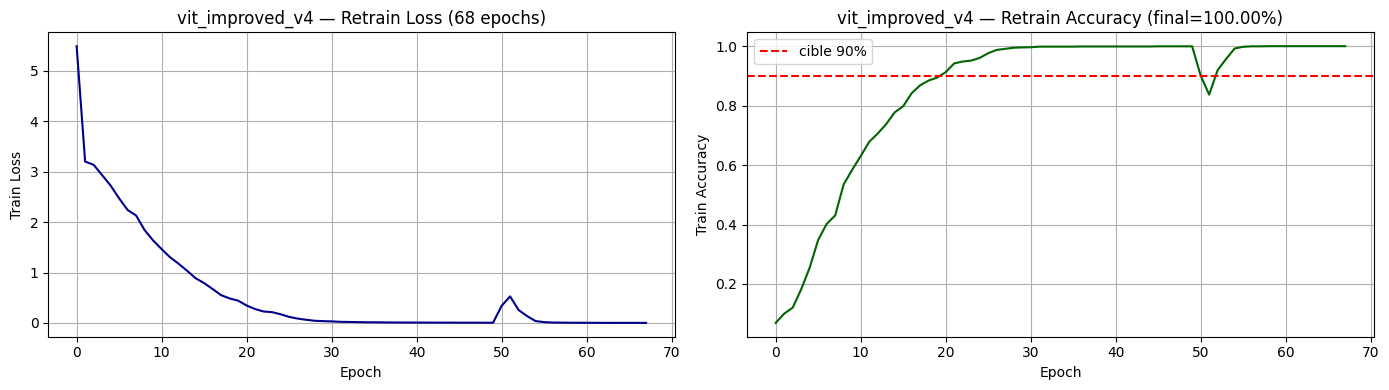

✅ Retrain converge : train acc = 100.00%


In [14]:
# Courbe de convergence du retrain — verifier que le modele a bien appris
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(final_history.history['loss'], color='darkblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train Loss')
axes[0].set_title(f'{MODEL_NAME} — Retrain Loss ({RETRAIN_EPOCHS} epochs)'); axes[0].grid(True)

axes[1].plot(final_history.history['accuracy'], color='darkgreen')
axes[1].axhline(0.90, color='red', linestyle='--', label='cible 90%')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Train Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Retrain Accuracy (final={final_train_acc:.2%})')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_retrain.png'), dpi=150, bbox_inches='tight')
plt.show()

if final_train_acc < 0.90:
    print(f"⚠️  Retrain train acc = {final_train_acc:.2%} < 90%. Le retrain n'a pas converge. Augmenter RETRAIN_EPOCHS_MULTIPLIER ou RETRAIN_EPOCHS_MIN.")
else:
    print(f"✅ Retrain converge : train acc = {final_train_acc:.2%}")

In [15]:
# Extract embeddings from the layer before softmax
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.get_layer('embedding').output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

I0000 00:00:1776548680.047682   60139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_352267__.19


 1/12 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

I0000 00:00:1776548681.117874   60139 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_352734__.19
I0000 00:00:1776548681.373742   74042 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776548681.732130   74041 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776548681.847130   74036 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_48', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1776548682.307429   74040 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 20 bytes spill stores, 20 bytes spill loads

I0000 00:00:1776548682.273540   74031 subprocess_compilation.cc:

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 335ms/step
Embedding shape: (371, 260)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_vit_improved_v4.csv


,row_id,similarity
0,0,0.790748
1,1,0.741004
2,2,0.761945
3,3,0.633335
4,4,0.769173


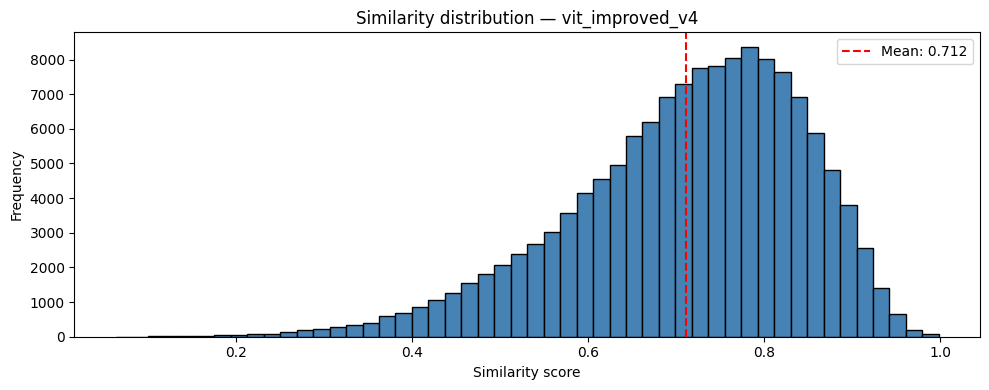

Similarity mean: 0.7117
Similarity std : 0.1329
Similarity min : 0.0633
Similarity max : 0.9985


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Similarity mean: {similarities.mean():.4f}")
print(f"Similarity std : {similarities.std():.4f}")
print(f"Similarity min : {similarities.min():.4f}")
print(f"Similarity max : {similarities.max():.4f}")

## 6. Observations & Verdict

In [18]:
print(f"""
ViT Naive v4 (tanh → relu):
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  LR: {BEST_LR}, Activation: {ACTIVATION}
  Embed dim: {EMBED_DIM}, Blocks: {NUM_BLOCKS}
  Best Epoch: {BEST_EPOCH}
  Embedding dim: {test_embeddings.shape[1]}
  Similarity mean: {similarities.mean():.4f}
""")


ViT Naive v4 (tanh → relu):
  Train - Loss: 0.3987, Acc: 0.9109
  Val   - Loss: 1.4184, Acc: 0.7071
  LR: 0.0001, Activation: relu
  Embed dim: 64, Blocks: 3
  Best Epoch: 17
  Embedding dim: 260
  Similarity mean: 0.7117



### Results

| Metrique | v3 | v4 |
|----------|-------|-----|
| Architecture | ViT + relu | ViT + relu (idem) |
| BEST_LR | 1e-4 | TODO |
| BEST_EPOCH (sweep) | 16 | TODO |
| Retrain epochs | 16 | TODO (>= 60) |
| Retrain train acc | **47.60 %** | TODO |
| Val accuracy (sweep) | 77.31 % | TODO |
| Similarity mean | 0.618 | TODO |
| Kaggle public | **0.097** | TODO |
| Kaggle private | **0.097** | TODO |

### Analysis

- TODO : Le retrain atteint-il > 90% train acc ? (cible pour embeddings discriminants)
- TODO : Distribution des similarites : plus bimodale que v3 (0.618) ?
- TODO : Score Kaggle vs v3 (0.097) : on devrait avoir un saut significatif
- TODO : Gap train/val sur le sweep : indication de l'overfitting a regulariser ensuite

### Verdict

- [ ] Improvable -> Instructions for v5 (probablement regularisation : AdamW, Dropout, data aug, label smoothing)
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff this architecture, why ?

### Interpretation

_Free Space : On note ce qu'on a a dire sur ce notebook, servira pour la soutenance._

Points cles a mentionner :
- Diagnostic de v3 : sweep et retrain decouples => important de monitorer la convergence du retrain, pas uniquement les metriques de sweep.
- Fix v4 : decouplage explicite via `RETRAIN_EPOCHS_MULTIPLIER`. Lecon generale applicable aux autres notebooks (ResNet aussi).